# CC3104 – Reinforcement Learning · Laboratorio 13
**Deep RL para el control continuo de turbinas eólicas: TD3, SAC y CQL**

**Entrega final – Task 1 y Task 2**

Integrante: **Carlos Alberto Valladares Guerra** – carné **221164**

Repositorio: [https://github.com/vgcarlol/Aprendizaje-Por-Refuerzo/tree/main/LABS/LAB8](https://github.com/vgcarlol/Aprendizaje-Por-Refuerzo/tree/main/LABS/LAB8)

| Parte | Contenido | Entrega |
|---|---|---|
| Task 1.1 | Justificación técnica de las decisiones de diseño | Parcial |
| Task 1.2 | Diferencias matemáticas entre SAC, TD3 y CQL | Parcial |
| Task 2.1 | TD3 y SAC desde cero sobre `Pendulum-v1` | Final |
| Task 2.2 | Dataset subóptimo + CQL offline | Final |
| Task 2.3 | Análisis de resultados e investigación bibliográfica | Final |

### Uso de IA generativa
Tal como pide el enunciado, declaramos el uso de IA generativa (Claude, de Anthropic).
- **Prompt utilizado:** *"Necesito hacer este laboratorio (se adjuntó el PDF del enunciado), por lo menos la entrega parcial. ¿Me ayudas? Hazlo todo en un Jupyter notebook."*
- **Por qué funcionó:** el enunciado completo da el contexto del caso (turbinas, acciones continuas, datos de operadores humanos) y las preguntas exactas, así que las respuestas se pudieron atar a cada inciso. El código se pidió con las especificaciones literales del enunciado (tamaños de buffer, τ, σ, c, arquitectura).
- **Revisión propia:** *(describe aquí qué revisaste, qué corregiste y qué partes reescribiste con tus palabras.)*

# Task 1 (Entrega parcial)

**Recomendación general.** Entrenar online en simulación con un método actor-critic para acciones continuas (SAC o TD3) y usar los registros históricos con CQL solo como punto de partida. Ninguna política aprendida de datos debería desplegarse sin validarla antes en el simulador.

## Task 1.1a – Por qué DQN no sirve con acciones continuas

DQN es inapropiado porque su regla de decisión y su target exigen un **argmax sobre todas las acciones**, y con un ángulo de pala continuo ese máximo no se puede enumerar.

DQN aprende $Q_\theta(s,a)$ con una red que tiene **una salida por acción discreta**. La política y el target de Bellman dependen del operador argmax:

$$\pi(s) = \arg\max_{a \in \mathcal{A}} Q_\theta(s,a), \qquad y = r + \gamma \max_{a'} Q_{\theta^-}(s',a')$$

Con $\mathcal{A} = [\theta_{\min}, \theta_{\max}] \subset \mathbb{R}$ (el ángulo de las palas) esto tiene tres consecuencias:

1. **No existe la arquitectura.** Una red con una salida por acción necesitaría infinitas salidas, y $Q(s,\cdot)$ pasa a ser una función continua y no convexa de $a$.
2. **El argmax se vuelve un problema de optimización interno.** En cada paso de control, y para cada transición del minibatch, habría que resolver $\max_a Q(s,a)$ por descenso de gradiente o muestreo (por ejemplo, CEM). Eso multiplica el costo por iteración y solo da un máximo aproximado, cuyo error se acumula en el *bootstrapping*.
3. **Discretizar no escala.** Con una resolución de 0.1° en un rango de 30° ya hay 300 acciones. Con $d$ dimensiones de control (paso de pala, *yaw*, torque del generador) el número de acciones crece como $k^d$: es la maldición de la dimensionalidad. Una malla gruesa pierde la precisión fina que necesita el control de palas. Una malla fina deja la mayoría de las acciones sin visitar, con estimaciones de $Q$ poco confiables, y empeora el sesgo de sobreestimación del $\max$.

Por eso se usan métodos **actor-critic** (DDPG, TD3, SAC). Un actor $\mu_\phi(s)$ produce directamente la acción continua y reemplaza al argmax: se entrena por gradiente para maximizar $Q(s,\mu_\phi(s))$, a costo de un solo *forward*.

## Task 1.1b – TD3 o SAC para producción

**Recomendamos entrenar con SAC en simulación y desplegar su acción determinista (la media de la política).** Si hay que elegir un solo algoritmo de punta a punta, elegimos **TD3**, por ser más simple de certificar y de auditar.

| Criterio | TD3 | SAC |
|---|---|---|
| Tipo de política | Determinista: $a=\mu_\phi(s)$ | Estocástica: $a\sim\pi_\phi(\cdot\mid s)$, gaussiana con tanh |
| Exploración | Ruido externo añadido a mano | Integrada en el objetivo mediante la entropía |
| Eficiencia de datos | Buena; sensible al ruido de exploración elegido | Suele ser mejor en tareas continuas; $\alpha$ se ajusta solo |
| Robustez a perturbaciones | Puede sobreajustarse a una trayectoria óptima estrecha | La máxima entropía aprende varias formas de actuar bien |
| Producción | Salida repetible y auditable | Hay que fijar la acción en la media para que sea determinista |

**A favor de TD3.** Una turbina es un sistema físico con actuadores que se desgastan. Una política estocástica en producción mueve las palas de forma aleatoria alrededor del óptimo, lo que aumenta la fatiga mecánica y las cargas sobre el rotor sin ganar energía. Además, el control industrial exige que la misma entrada produzca la misma salida, para poder certificar y depurar. TD3 lo da por diseño, y sus *twin critics* con el mínimo reducen la sobreestimación del valor.

**A favor de SAC.** En simulación, la estocasticidad es una ventaja. El objetivo de máxima entropía explora sin calibrar el ruido a mano y, en tareas continuas, suele alcanzar buen desempeño con menos interacción (mejor eficiencia de datos). Como premia mantener varias acciones buenas, la política resultante es más robusta ante ráfagas de viento que no aparecieron en el entrenamiento: una política que solo conoce un camino falla cuando el estado se sale de él.

**Posición.** El argumento físico contra la política estocástica aplica al **despliegue**, no al **entrenamiento**. Por eso proponemos SAC en simulación, con randomización del viento (*domain randomization*) para ganar robustez, y en producción la acción determinista $a=\tanh(\mu_\phi(s))$, sin muestrear. Si el equipo no puede validar ese cambio de comportamiento entre entrenamiento y despliegue, TD3 es la opción segura. En ambos casos debe haber límites de seguridad en la tasa de cambio del ángulo (*rate limiter*) fuera de la política. La Task 2.3a comprueba en `Pendulum-v1` si SAC efectivamente converge más rápido.

## Task 1.1c – ¿El dataset histórico es apropiado para CQL?

Es **apropiado con reservas**. CQL está diseñado justamente para datos subóptimos y mezclados, pero la cobertura de un dataset humano es estrecha, y eso limita cuánto puede mejorar la política aprendida sobre la de los operadores.

**Política de comportamiento $\beta$.** Los datos no vienen de una sola política, sino de una **mezcla** de operadores: $\beta=\sum_k w_k\,\beta_k$, con expertos cercanos al óptimo y novatos lejos de él. En conjunto, $\beta$ es subóptima y multimodal: para un mismo estado de viento hay varias acciones registradas de calidad muy distinta. Esto favorece a CQL frente a la clonación de comportamiento (BC). BC imitaría el promedio de los operadores, errores incluidos; CQL usa las recompensas para quedarse con las mejores acciones que sí aparecen en los datos.

**Cobertura del espacio estado-acción.** Se espera que sea **estrecha y sesgada**:
- Las personas operan con reglas aprendidas y procedimientos fijos, con poca variación del ángulo para un mismo viento. Casi no exploran.
- Los estados extremos (ráfagas, vientos fuera de diseño) son raros. Cuando ocurren, el protocolo suele ser conservador (embanderar las palas o detener la turbina), así que casi no hay acciones alternativas registradas en ellos.
- Las acciones riesgosas que podrían ser mejores nunca se probaron, por seguridad. No hay datos sobre cuánto valen.

**Las dos condiciones de Offline RL.** Para aprender una buena política sin interactuar se necesita (1) **calidad**: que $\beta$ contenga acciones buenas; y (2) **cobertura**: que los pares $(s,a)$ relevantes para la política aprendida estén representados, $\beta(a\mid s)>0$ donde $\pi$ actúa. En este dominio la condición más difícil es la **cobertura**. La calidad se cumple en parte, porque los operadores expertos están en el dataset. Pero ningún registro humano cubre las acciones fuera de su rutina ni los estados raros de viento. Esas son justamente las regiones donde una política nueva podría ganarles a los humanos, y donde Q-Learning más se equivoca. En la práctica, CQL puede igualar o superar a los mejores operadores dentro de la región cubierta, pero no descubrirá estrategias radicalmente distintas.

**Preprocesamiento recomendado:** etiquetar los registros por operador o por desempeño, revisar qué tan cubiertos están los regímenes de viento antes de entrenar, y validar la política en el simulador antes de cualquier despliegue.

## Task 1.1d – Riesgo de Q-Learning sin conservatividad sobre los datos históricos

El riesgo principal es el **error de extrapolación**: el target de Bellman evalúa acciones que no están en los datos, la red les asigna valores inventados, el $\max$ elige justamente los más inflados y el *bootstrapping* los propaga sin que ninguna interacción los corrija.

$$y = r + \gamma \max_{a'} Q_{\theta^-}(s',a')$$

El $\max_{a'}$ (o el actor que lo aproxima) recorre todo $\mathcal{A}$, incluidas acciones *out-of-distribution* (OOD) con $\beta(a'\mid s')\approx 0$. Para esas acciones, $Q$ es pura extrapolación de la red. En online, el agente las probaría, observaría la recompensa real y corregiría el error. En offline eso nunca ocurre: el error positivo se vuelve el target de otros estados, se acumula paso a paso y $Q$ puede divergir. La política resultante elige con confianza las acciones que **menos** se conocen.

**Consecuencia operacional concreta.** Ante ráfagas fuertes, los operadores siempre embanderaron las palas (ángulo alto, poca captura de viento), así que el dataset no contiene qué pasa con un ángulo agresivo y viento fuerte. La red puede extrapolar que un ángulo de captura máxima con viento de 20 m/s produce muchísima energía, porque nunca vio la penalización. La política aprendida haría justo eso: **sobrevelocidad del rotor, sobrecargas estructurales en palas y torre, disparo de las protecciones y paro de emergencia**, o daño físico al equipo. Esa pérdida supera cualquier ganancia de generación.

## Task 1.2a – Objetivo de SAC con entropía

SAC maximiza la recompensa **más** la entropía de la política, ponderada por la temperatura $\alpha$:

$$J(\pi) = \sum_{t} \mathbb{E}_{(s_t,a_t)\sim\rho_\pi}\Big[\, r(s_t,a_t) + \alpha\, \mathcal{H}\big(\pi(\cdot\mid s_t)\big) \Big], \qquad \mathcal{H}\big(\pi(\cdot\mid s_t)\big) = -\mathbb{E}_{a\sim\pi}\big[\log \pi(a\mid s_t)\big]$$

| Variable | Significado en el sistema de turbinas |
|---|---|
| $s_t$ | Estado: velocidad y dirección del viento, velocidad del rotor, ángulo actual de las palas, potencia generada |
| $a_t$ | Ajuste continuo del ángulo de las palas |
| $r(s_t,a_t)$ | Energía generada en el paso, menos penalizaciones por cargas o movimientos bruscos |
| $\mathcal{H}(\pi(\cdot\mid s_t))$ | Qué tan "abierta" es la política: cuánta variedad de ángulos considera buenos en ese estado de viento |
| $\alpha$ | Temperatura: cuánto vale la diversidad de acciones frente a un kWh más. $\alpha$ alto = explora mucho; $\alpha\to 0$ = maximiza solo energía (se acerca a TD3) |
| $\gamma$ | Descuento: cuánto pesa la energía futura frente a la inmediata |

**Calibración automática de $\alpha$.** En lugar de fijar $\alpha$ a mano, se plantea una restricción: la entropía promedio debe ser al menos un objetivo $\bar{\mathcal{H}}$, que por convención es $-\dim(\mathcal{A})$ ($=-1$ con un solo ángulo). $\alpha$ actúa como multiplicador de Lagrange y se aprende por descenso de gradiente sobre

$$J(\alpha) = \mathbb{E}_{a_t\sim\pi_t}\big[-\alpha \log\pi_t(a_t\mid s_t) - \alpha\,\bar{\mathcal{H}}\big].$$

Si la política se vuelve demasiado determinista (entropía por debajo del objetivo), $\alpha$ sube y empuja a explorar. Si explora de más, $\alpha$ baja. En la práctica se optimiza $\log\alpha$ para mantener $\alpha>0$.

## Task 1.2b – Target del Critic: TD3 frente a SAC

**TD3** (*clipped double-Q* + *target policy smoothing*):

$$y_{\text{TD3}} = r + \gamma (1-d) \min_{i=1,2} Q_{\theta_i'}\big(s', \tilde a'\big), \qquad \tilde a' = \operatorname{clip}\big(\mu_{\phi'}(s') + \epsilon,\, a_{\min}, a_{\max}\big),\quad \epsilon\sim\operatorname{clip}(\mathcal{N}(0,\sigma), -c, c)$$

**SAC** (*clipped double-Q* + término de entropía):

$$y_{\text{SAC}} = r + \gamma (1-d)\Big(\min_{i=1,2} Q_{\theta_i'}(s', \tilde a') - \alpha \log \pi_\phi(\tilde a'\mid s')\Big), \qquad \tilde a' \sim \pi_\phi(\cdot\mid s')$$

Ambos toman el **mínimo de dos críticos**, lo que corrige la sobreestimación de DDPG. Las diferencias son dos:

1. TD3 evalúa el target con la acción determinista más ruido recortado. Eso suaviza $Q$ alrededor de la acción y evita explotar picos estrechos y espurios del crítico.
2. SAC suma $-\alpha\log\pi = $ un **bono de entropía** en cada paso. Su $Q$ es un *soft Q-value*, que incluye la entropía futura además de la recompensa.

**Cuál es más conservador.** **TD3 produce estimaciones más conservadoras.** El mínimo de dos críticos tiene sesgo hacia abajo y, al no añadir ningún bono, ese sesgo no se compensa. SAC, en cambio, infla el valor con el bono de entropía: con la entropía objetivo, $-\log\pi$ es en promedio positivo, así que se suma algo cercano a $+\alpha$ por cada paso futuro. Esperamos ver **valores $Q$ de TD3 por debajo de los de SAC** en la Task 2.3b.

**¿Ventaja o desventaja en turbinas?** Mayormente es una **ventaja**. Subestimar el valor de una maniobra hace que la política prefiera ángulos conocidos y seguros, en lugar de perseguir acciones cuyo valor alto podría ser un error del crítico. Sobreestimar, en cambio, lleva directamente a sobrecargas mecánicas. La desventaja es que una subestimación excesiva puede dejar energía sin capturar o hacer más lenta la convergencia. Por eso conviene vigilar la brecha entre el $Q$ estimado y el retorno real observado.

## Task 1.2c – Objetivo de CQL

CQL (Kumar et al., 2020) añade a la pérdida TD un regularizador con **dos términos** que se oponen:

$$\min_{Q}\; \alpha_{\text{CQL}}\Big(\underbrace{\mathbb{E}_{s\sim\mathcal{D}}\Big[\log\sum_{a}\exp Q(s,a)\Big]}_{\text{(1) baja } Q \text{ en todas las acciones}} \;-\; \underbrace{\mathbb{E}_{(s,a)\sim\mathcal{D}}\big[Q(s,a)\big]}_{\text{(2) sube } Q \text{ en las acciones del dataset}}\Big) \;+\; \frac{1}{2}\,\mathbb{E}_{(s,a,s')\sim\mathcal{D}}\Big[\big(Q(s,a) - \hat{\mathcal{B}}^{\pi}\bar Q(s,a)\big)^2\Big]$$

- **Término (1), log-sum-exp.** Es un máximo suave de $Q$ sobre todas las acciones. Minimizarlo empuja hacia abajo los valores más altos en cualquier lugar del espacio de acciones, sobre todo las acciones OOD que el crítico infló por extrapolación. Con acciones continuas, la suma se aproxima muestreando acciones uniformes y acciones de la política actual, con *importance sampling*.
- **Término (2), media sobre el dataset.** Empuja hacia arriba el valor de las acciones que **sí** tomaron los operadores, para que el término (1) no hunda también lo que está respaldado por datos.
- **Combinación.** La diferencia (1) − (2) es grande cuando el crítico valora más una acción no vista que las acciones observadas. Penalizarla hace que $Q$ sea una **cota inferior** del valor real fuera del soporte de los datos, sin dejar de aprender bien dentro de él. El actor, que maximiza $Q$, queda entonces cerca de las acciones respaldadas por datos: un crítico conservador.

**$\alpha_{\text{CQL}}$ recomendado para el dataset de turbinas: alto, alrededor de 5,** ajustándolo después con validación en simulación. Los argumentos:
- La cobertura de operadores humanos es estrecha (Task 1.1c), así que hay muchas acciones OOD y el riesgo de extrapolación es alto. Un error se paga en daño físico.
- La heterogeneidad de los operadores sí aporta varias acciones registradas por estado. Eso permite que, incluso con $\alpha$ alto, la política elija entre las acciones observadas la de mayor recompensa, sin limitarse a imitar el promedio.
- Si $\alpha$ fuera excesivo, CQL degeneraría en clonación del comportamiento promedio, que incluye a los operadores novatos. Por eso conviene la versión de Lagrange de CQL (un umbral sobre la brecha (1) − (2) que ajusta $\alpha$ solo), o elegir $\alpha$ con evaluación en el simulador.

La Task 2.2 compara $\alpha_{\text{CQL}}\in\{0.5,\,1.0,\,5.0\}$ en `Pendulum-v1`.

# Task 2 (Entrega final)

Todo se implementa desde cero en PyTorch, sin librerías de RL. Las especificaciones compartidas son las del enunciado: buffer de 100,000 transiciones, minibatch de 256, $\tau=0.005$, dos capas ocultas de 256 neuronas con ReLU y 100,000 pasos de ambiente.

**Convención de acciones.** El actor trabaja en el rango normalizado $[-1,1]$ y la acción que recibe el ambiente es $2a$, porque `Pendulum-v1` acepta torques en $[-2,2]$. Así el ruido de TD3 ($\sigma=0.2$, $c=0.5$) se aplica en la misma escala que en el paper original, y CQL muestrea acciones uniformes en $[-1,1]$.

> Para una prueba rápida del código, ejecuten con la variable de entorno `LAB_RAPIDO=1` (pocos pasos). La corrida completa toma alrededor de una hora en CPU.

In [1]:
import os, time, json, random, copy
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import gymnasium as gym
import matplotlib.pyplot as plt

RAPIDO = os.environ.get('LAB_RAPIDO') == '1'   # prueba corta del código
SEED = 0
DEVICE = torch.device('cpu')                   # redes pequeñas: en CPU es más rápido que en GPU/MPS
torch.set_num_threads(4)

ENV_ID = 'Pendulum-v1'
PASOS_ONLINE   = 3_000  if RAPIDO else 100_000   # Task 2.1: pasos de ambiente
EVAL_CADA      = 1_000                            # registrar métricas cada 1,000 pasos
EPISODIOS_EVAL = 2      if RAPIDO else 10         # evaluación greedy sobre 10 episodios
PASOS_SUBOPT   = 2_000  if RAPIDO else 20_000     # Task 2.2: TD3 sin convergencia completa
TRANS_DATASET  = 5_000  if RAPIDO else 50_000     # transiciones del dataset offline
UPD_CQL        = 2_000  if RAPIDO else 100_000    # actualizaciones de CQL por cada alpha
ALPHAS_CQL     = [0.5, 1.0, 5.0]

BUFFER, BATCH, TAU, GAMMA, OCULTAS, LR = 100_000, 256, 0.005, 0.99, 256, 3e-4
PASOS_ALEATORIOS = 1_000   # acciones uniformes al inicio para llenar el buffer

def fijar_semilla(seed):
    random.seed(seed); np.random.seed(seed); torch.manual_seed(seed)

env_tmp = gym.make(ENV_ID)
S_DIM = env_tmp.observation_space.shape[0]        # 3: (cos θ, sin θ, θ̇)
A_DIM = env_tmp.action_space.shape[0]             # 1: torque
A_MAX = float(env_tmp.action_space.high[0])       # 2.0
print(f'Estado: {S_DIM} dims · Acción: {A_DIM} dim en [-{A_MAX}, {A_MAX}] · modo rápido: {RAPIDO}')

Estado: 3 dims · Acción: 1 dim en [-2.0, 2.0] · modo rápido: False


In [2]:
class ReplayBuffer:
    '''Experience Replay: guarda (s, a, r, s', d) y muestrea minibatches uniformes,
    lo que rompe la correlación temporal entre transiciones consecutivas.'''
    def __init__(self, capacidad, s_dim, a_dim):
        self.cap, self.i, self.n = capacidad, 0, 0
        self.s  = np.zeros((capacidad, s_dim), np.float32)
        self.a  = np.zeros((capacidad, a_dim), np.float32)
        self.r  = np.zeros((capacidad, 1), np.float32)
        self.s2 = np.zeros((capacidad, s_dim), np.float32)
        self.d  = np.zeros((capacidad, 1), np.float32)

    def agregar(self, s, a, r, s2, d):
        self.s[self.i], self.a[self.i], self.r[self.i], self.s2[self.i], self.d[self.i] = s, a, r, s2, d
        self.i = (self.i + 1) % self.cap          # buffer circular: reemplaza lo más viejo
        self.n = min(self.n + 1, self.cap)

    def muestrear(self, k):
        idx = np.random.randint(0, self.n, size=k)
        t = lambda x: torch.as_tensor(x[idx], device=DEVICE)
        return t(self.s), t(self.a), t(self.r), t(self.s2), t(self.d)


def mlp(entrada, salida):
    '''Dos capas ocultas de 256 neuronas con ReLU (arquitectura compartida por TD3, SAC y CQL).'''
    return nn.Sequential(nn.Linear(entrada, OCULTAS), nn.ReLU(),
                         nn.Linear(OCULTAS, OCULTAS), nn.ReLU(),
                         nn.Linear(OCULTAS, salida))


class TwinCritic(nn.Module):
    '''Dos críticos independientes Q_θ1(s,a) y Q_θ2(s,a): el mínimo de ambos combate la sobreestimación.'''
    def __init__(self):
        super().__init__()
        self.q1, self.q2 = mlp(S_DIM + A_DIM, 1), mlp(S_DIM + A_DIM, 1)
    def forward(self, s, a):
        sa = torch.cat([s, a], dim=-1)
        return self.q1(sa), self.q2(sa)


def actualizacion_suave(red, objetivo, tau=TAU):
    '''Target networks con Polyak: θ' ← τ·θ + (1 − τ)·θ'.'''
    with torch.no_grad():
        for p, pt in zip(red.parameters(), objetivo.parameters()):
            pt.mul_(1 - tau).add_(tau * p)

### TD3: Twin Delayed DDPG

- **Twin critics:** $y = r + \gamma(1-d)\min_{i} Q_{\theta_i'}(s',\tilde a')$.
- **Target policy smoothing:** $\tilde a' = \operatorname{clip}\big(\mu_{\phi'}(s') + \operatorname{clip}(\epsilon,-c,c)\big)$, con $\epsilon\sim\mathcal{N}(0,\sigma)$, $\sigma=0.2$ y $c=0.5$.
- **Policy delay:** el actor y las *target networks* se actualizan cada 2 pasos del crítico, maximizando $\mathbb{E}[Q_{\theta_1}(s,\mu_\phi(s))]$.

In [3]:
class ActorDeterminista(nn.Module):
    '''μ_φ(s) ∈ [-1, 1]: tanh a la salida para respetar el rango de la acción.'''
    def __init__(self):
        super().__init__()
        self.red = mlp(S_DIM, A_DIM)
    def forward(self, s):
        return torch.tanh(self.red(s))


class TD3:
    def __init__(self, sigma=0.2, c=0.5, retraso=2, ruido_expl=0.1):
        self.actor, self.critic = ActorDeterminista().to(DEVICE), TwinCritic().to(DEVICE)
        self.actor_t, self.critic_t = copy.deepcopy(self.actor), copy.deepcopy(self.critic)   # target networks
        self.opt_a = torch.optim.Adam(self.actor.parameters(), lr=LR)
        self.opt_c = torch.optim.Adam(self.critic.parameters(), lr=LR)
        self.sigma, self.c, self.retraso, self.ruido_expl, self.it = sigma, c, retraso, ruido_expl, 0

    @torch.no_grad()
    def actuar(self, s, explorar=False):
        a = self.actor(torch.as_tensor(s, dtype=torch.float32, device=DEVICE)).cpu().numpy()
        if explorar:                                # exploración: ruido gaussiano externo
            a = a + np.random.normal(0, self.ruido_expl, size=A_DIM)
        return np.clip(a, -1, 1)

    @torch.no_grad()
    def accion_greedy(self, s_t):                   # para medir Q(s, π(s)) en el conjunto fijo
        return self.actor(s_t)

    def actualizar(self, lote):
        s, a, r, s2, d = lote
        self.it += 1
        with torch.no_grad():
            # Target policy smoothing: ε ~ clip(N(0, σ), −c, c)
            eps = (torch.randn_like(a) * self.sigma).clamp(-self.c, self.c)
            a2 = (self.actor_t(s2) + eps).clamp(-1, 1)
            q1_t, q2_t = self.critic_t(s2, a2)
            y = r + GAMMA * (1 - d) * torch.min(q1_t, q2_t)          # clipped double-Q
        q1, q2 = self.critic(s, a)
        loss_c = F.mse_loss(q1, y) + F.mse_loss(q2, y)
        self.opt_c.zero_grad(); loss_c.backward(); self.opt_c.step()

        if self.it % self.retraso == 0:                                # policy delay = 2
            loss_a = -self.critic(s, self.actor(s))[0].mean()         # max_φ E[Q_θ1(s, μ_φ(s))]
            self.opt_a.zero_grad(); loss_a.backward(); self.opt_a.step()
            actualizacion_suave(self.actor, self.actor_t)
            actualizacion_suave(self.critic, self.critic_t)

### SAC: Soft Actor-Critic

- **Política gaussiana reparametrizada:** $u = \mu_\phi(s) + \sigma_\phi(s)\odot\xi$, con $\xi\sim\mathcal{N}(0,I)$ y $a=\tanh(u)$. Por el cambio de variable, $\log\pi(a\mid s) = \log\mathcal{N}(u;\mu,\sigma) - \sum_j \log(1-\tanh^2 u_j)$.
- **Target del crítico:** $y = r + \gamma(1-d)\big(\min_i Q_{\theta_i'}(s',\tilde a') - \alpha\log\pi(\tilde a'\mid s')\big)$, con $\tilde a'\sim\pi(\cdot\mid s')$.
- **Actor:** minimiza $\mathbb{E}\big[\alpha\log\pi(a\mid s) - \min_i Q_{\theta_i}(s,a)\big]$.
- **Temperatura automática:** $J(\alpha) = \mathbb{E}\big[-\alpha(\log\pi(a\mid s) + \bar{\mathcal{H}})\big]$, con $\bar{\mathcal{H}} = -\dim(\mathcal{A}) = -1$.

In [4]:
class ActorGaussiano(nn.Module):
    '''π_φ(a|s): gaussiana diagonal sobre u, aplastada con tanh para que a ∈ [-1, 1].'''
    def __init__(self):
        super().__init__()
        self.base = nn.Sequential(nn.Linear(S_DIM, OCULTAS), nn.ReLU(), nn.Linear(OCULTAS, OCULTAS), nn.ReLU())
        self.media, self.log_std = nn.Linear(OCULTAS, A_DIM), nn.Linear(OCULTAS, A_DIM)

    def forward(self, s):
        h = self.base(s)
        return self.media(h), self.log_std(h).clamp(-20, 2)

    def muestrear(self, s):
        media, log_std = self(s)
        std = log_std.exp()
        u = media + std * torch.randn_like(media)              # truco de reparametrización
        a = torch.tanh(u)
        # log π(a|s) = log N(u; μ, σ) − Σ log(1 − tanh²(u))   (corrección por el cambio de variable)
        log_p = (-0.5 * ((u - media) / std) ** 2 - log_std - 0.5 * np.log(2 * np.pi)).sum(-1, keepdim=True)
        log_p = log_p - torch.log(1 - a.pow(2) + 1e-6).sum(-1, keepdim=True)
        return a, log_p


class SAC:
    def __init__(self):
        self.actor, self.critic = ActorGaussiano().to(DEVICE), TwinCritic().to(DEVICE)
        self.critic_t = copy.deepcopy(self.critic)
        self.opt_a = torch.optim.Adam(self.actor.parameters(), lr=LR)
        self.opt_c = torch.optim.Adam(self.critic.parameters(), lr=LR)
        self.log_alpha = torch.zeros(1, requires_grad=True, device=DEVICE)   # se optimiza log α para que α > 0
        self.opt_alpha = torch.optim.Adam([self.log_alpha], lr=LR)
        self.entropia_objetivo = -float(A_DIM)                                 # H̄ = −dim(A)

    @property
    def alpha(self):
        return self.log_alpha.exp().detach()

    @torch.no_grad()
    def actuar(self, s, explorar=False):
        s_t = torch.as_tensor(s, dtype=torch.float32, device=DEVICE)
        a = self.actor.muestrear(s_t)[0] if explorar else torch.tanh(self.actor(s_t)[0])   # greedy = tanh(μ)
        return a.cpu().numpy()

    @torch.no_grad()
    def accion_greedy(self, s_t):
        return torch.tanh(self.actor(s_t)[0])

    @torch.no_grad()
    def entropia(self, s_t):
        '''Estimación Monte Carlo de H(π(·|s)) = −E[log π(a|s)] sobre estados fijos.'''
        return -self.actor.muestrear(s_t)[1].mean().item()

    def target(self, r, s2, d):
        with torch.no_grad():
            a2, logp2 = self.actor.muestrear(s2)
            q1_t, q2_t = self.critic_t(s2, a2)
            return r + GAMMA * (1 - d) * (torch.min(q1_t, q2_t) - self.alpha * logp2)   # soft Bellman

    def paso_actor_y_alpha(self, s):
        a, logp = self.actor.muestrear(s)
        q1, q2 = self.critic(s, a)
        loss_a = (self.alpha * logp - torch.min(q1, q2)).mean()
        self.opt_a.zero_grad(); loss_a.backward(); self.opt_a.step()
        # J(α) = E[−α (log π + H̄)]: si la entropía cae bajo el objetivo, α sube
        loss_alpha = -(self.log_alpha * (logp.detach() + self.entropia_objetivo)).mean()
        self.opt_alpha.zero_grad(); loss_alpha.backward(); self.opt_alpha.step()

    def actualizar(self, lote):
        s, a, r, s2, d = lote
        y = self.target(r, s2, d)
        q1, q2 = self.critic(s, a)
        loss_c = F.mse_loss(q1, y) + F.mse_loss(q2, y)
        self.opt_c.zero_grad(); loss_c.backward(); self.opt_c.step()
        self.paso_actor_y_alpha(s)
        actualizacion_suave(self.critic, self.critic_t)

### Entrenamiento online y métricas

Cada 1,000 pasos se registran:
- la recompensa promedio de una evaluación **greedy** sobre 10 episodios;
- el **valor $Q$ promedio** sobre un conjunto fijo de 1,000 transiciones: $\tfrac{1}{2}\big(Q_{\theta_1}+Q_{\theta_2}\big)(s,\pi(s))$, el mismo conjunto para ambos algoritmos;
- la **entropía** de la política (solo SAC).

In [5]:
def evaluar(agente, episodios=EPISODIOS_EVAL, seed=10_000):
    '''Recompensa promedio de la política greedy (sin ruido) sobre varios episodios.'''
    env, total = gym.make(ENV_ID), []
    for ep in range(episodios):
        s, _ = env.reset(seed=seed + ep)
        terminado, ret = False, 0.0
        while not terminado:
            s, r, term, trunc, _ = env.step(A_MAX * agente.actuar(s, explorar=False))
            ret += r; terminado = term or trunc
        total.append(ret)
    return float(np.mean(total))


def conjunto_fijo(n=1_000, seed=123):
    '''1,000 estados fijos (de una política aleatoria) para comparar Q entre algoritmos.'''
    env, estados = gym.make(ENV_ID), []
    s, _ = env.reset(seed=seed)
    rng = np.random.default_rng(seed)
    while len(estados) < n:
        estados.append(s)
        s, _, term, trunc, _ = env.step(rng.uniform(-A_MAX, A_MAX, size=A_DIM))
        if term or trunc: s, _ = env.reset()
    return torch.as_tensor(np.array(estados), dtype=torch.float32, device=DEVICE)

ESTADOS_FIJOS = conjunto_fijo()

@torch.no_grad()
def q_promedio(agente):
    q1, q2 = agente.critic(ESTADOS_FIJOS, agente.accion_greedy(ESTADOS_FIJOS))
    return float(((q1 + q2) / 2).mean())


def entrenar_online(agente, nombre, pasos, seed=SEED):
    fijar_semilla(seed)
    env = gym.make(ENV_ID)
    buffer = ReplayBuffer(BUFFER, S_DIM, A_DIM)
    s, _ = env.reset(seed=seed)
    registro, t0 = [], time.time()
    for t in range(1, pasos + 1):
        a = np.random.uniform(-1, 1, A_DIM) if t <= PASOS_ALEATORIOS else agente.actuar(s, explorar=True)
        s2, r, term, trunc, _ = env.step(A_MAX * a)
        buffer.agregar(s, a, r, s2, float(term))    # solo 'terminated' corta el bootstrap; el truncamiento por tiempo no
        s = s2
        if term or trunc: s, _ = env.reset()
        if buffer.n >= BATCH: agente.actualizar(buffer.muestrear(BATCH))
        if t % EVAL_CADA == 0:
            fila = {'paso': t, 'recompensa': evaluar(agente), 'q': q_promedio(agente)}
            if isinstance(agente, SAC): fila.update(entropia=agente.entropia(ESTADOS_FIJOS), alpha=agente.alpha.item())
            registro.append(fila)
            if t % (10 * EVAL_CADA) == 0 or RAPIDO:
                extra = f" · H={fila['entropia']:.2f} · α={fila['alpha']:.3f}" if 'entropia' in fila else ''
                print(f"[{nombre}] paso {t:>6} · recompensa {fila['recompensa']:8.1f} · Q {fila['q']:8.1f}{extra} · {time.time()-t0:5.0f}s")
    return registro

## Task 2.1 – Entrenamiento de TD3 y SAC

In [6]:
td3 = TD3()
registro_td3 = entrenar_online(td3, 'TD3', PASOS_ONLINE)

[TD3] paso  10000 · recompensa   -114.6 · Q   -113.3 ·    17s


[TD3] paso  20000 · recompensa   -108.2 · Q   -154.2 ·    34s


[TD3] paso  30000 · recompensa   -112.2 · Q   -155.3 ·    52s


[TD3] paso  40000 · recompensa   -112.7 · Q   -152.0 ·    69s


[TD3] paso  50000 · recompensa   -122.5 · Q   -152.8 ·    86s


[TD3] paso  60000 · recompensa   -121.4 · Q   -154.9 ·   103s


[TD3] paso  70000 · recompensa   -110.6 · Q   -158.8 ·   121s


[TD3] paso  80000 · recompensa   -112.8 · Q   -161.2 ·   138s


[TD3] paso  90000 · recompensa   -118.7 · Q   -161.7 ·   156s


[TD3] paso 100000 · recompensa   -117.7 · Q   -161.9 ·   173s


In [7]:
sac = SAC()
registro_sac = entrenar_online(sac, 'SAC', PASOS_ONLINE)

[SAC] paso  10000 · recompensa   -109.7 · Q   -154.3 · H=-2.46 · α=0.105 ·    24s


[SAC] paso  20000 · recompensa   -109.2 · Q   -145.2 · H=-3.42 · α=0.030 ·    50s


[SAC] paso  30000 · recompensa   -111.4 · Q   -146.0 · H=-3.32 · α=0.022 ·    75s


[SAC] paso  40000 · recompensa   -109.6 · Q   -147.5 · H=-3.07 · α=0.033 ·   101s


[SAC] paso  50000 · recompensa   -109.3 · Q   -147.3 · H=-3.53 · α=0.024 ·   126s


[SAC] paso  60000 · recompensa   -109.9 · Q   -146.3 · H=-3.36 · α=0.024 ·   151s


[SAC] paso  70000 · recompensa   -109.5 · Q   -146.8 · H=-3.44 · α=0.023 ·   176s


[SAC] paso  80000 · recompensa   -108.6 · Q   -146.7 · H=-3.88 · α=0.020 ·   202s


[SAC] paso  90000 · recompensa   -109.2 · Q   -147.8 · H=-3.64 · α=0.021 ·   226s


[SAC] paso 100000 · recompensa   -109.0 · Q   -147.6 · H=-4.73 · α=0.012 ·   252s


## Task 2.2 – Dataset subóptimo y CQL

1. TD3 se entrena solo 20,000 pasos (sin convergencia completa).
2. Se recolectan 50,000 transiciones con esa política más ruido gaussiano $\mathcal{N}(0, 0.3)$ sobre el torque (en unidades del ambiente). Esto simula operadores humanos de desempeño heterogéneo.
3. Se registra la recompensa de la **política de comportamiento** (con ruido), que es la que generó los datos, y también la de la política subóptima greedy.

In [8]:
td3_sub = TD3()
_ = entrenar_online(td3_sub, 'TD3-subóptimo', PASOS_SUBOPT, seed=SEED + 1)

def recolectar_dataset(agente, n, sigma=0.3, seed=SEED + 2):
    fijar_semilla(seed)
    env, datos = gym.make(ENV_ID), ReplayBuffer(n, S_DIM, A_DIM)
    s, _ = env.reset(seed=seed)
    retornos, ret = [], 0.0
    while datos.n < n:
        # a = clip(μ(s)·A_MAX + N(0, 0.3), −2, 2): ruido sobre el torque real
        a_env = np.clip(A_MAX * agente.actuar(s) + np.random.normal(0, sigma, A_DIM), -A_MAX, A_MAX)
        s2, r, term, trunc, _ = env.step(a_env)
        datos.agregar(s, a_env / A_MAX, r, s2, float(term))   # se guarda normalizada a [−1, 1]
        ret += r; s = s2
        if term or trunc:
            retornos.append(ret); ret = 0.0; s, _ = env.reset()
    return datos, float(np.mean(retornos))

dataset, recompensa_comportamiento = recolectar_dataset(td3_sub, TRANS_DATASET)
recompensa_suboptima_greedy = evaluar(td3_sub)
print(f'Dataset: {dataset.n} transiciones')
print(f'Recompensa de la política de comportamiento (con ruido): {recompensa_comportamiento:.1f}')
print(f'Recompensa de la política subóptima greedy (sin ruido):  {recompensa_suboptima_greedy:.1f}')

[TD3-subóptimo] paso  10000 · recompensa   -351.2 · Q   -112.0 ·    17s


[TD3-subóptimo] paso  20000 · recompensa   -110.3 · Q   -152.4 ·    34s


Dataset: 50000 transiciones
Recompensa de la política de comportamiento (con ruido): -155.7
Recompensa de la política subóptima greedy (sin ruido):  -110.3


### CQL (sobre SAC, variante CQL(H))

El crítico minimiza la pérdida TD de SAC más el regularizador conservador:

$$\mathcal{L}(\theta) = \underbrace{\tfrac12\,\mathbb{E}_{\mathcal{D}}\big[(Q_\theta(s,a) - y)^2\big]}_{\text{TD estándar}} + \alpha_{\text{CQL}}\Big(\mathbb{E}_{s\sim\mathcal{D}}\big[\log\textstyle\sum_a e^{Q_\theta(s,a)}\big] - \mathbb{E}_{(s,a)\sim\mathcal{D}}\big[Q_\theta(s,a)\big]\Big)$$

El $\log\sum\exp$ sobre acciones continuas se estima con *importance sampling*, usando 10 acciones uniformes en $[-1,1]$ (densidad $2^{-1}$) y 10 acciones de la política en $s$ y en $s'$:

$$\log\sum_a e^{Q(s,a)} \approx \log\Big(\frac{1}{3N}\sum_{j}\frac{e^{Q(s,a_j)}}{q(a_j)}\Big)$$

El actor y $\alpha$ de entropía se actualizan igual que en SAC. No hay ninguna interacción con el ambiente durante el entrenamiento.

In [9]:
class CQL(SAC):
    def __init__(self, alpha_cql, n_acciones=10):
        super().__init__()
        self.alpha_cql, self.N = alpha_cql, n_acciones

    def _q_muestras(self, s_rep, a):
        q1, q2 = self.critic(s_rep, a)
        return q1.view(-1, self.N), q2.view(-1, self.N)

    def actualizar(self, lote):
        s, a, r, s2, d = lote
        B = s.shape[0]
        y = self.target(r, s2, d)
        q1, q2 = self.critic(s, a)
        perdida_td = F.mse_loss(q1, y) + F.mse_loss(q2, y)

        # ── Regularizador CQL: log Σ_a exp Q(s,a)  −  Q(s, a_dataset) ──
        s_rep, s2_rep = s.repeat_interleave(self.N, 0), s2.repeat_interleave(self.N, 0)
        a_unif = torch.empty(B * self.N, A_DIM, device=DEVICE).uniform_(-1, 1)
        logq_unif = np.log(0.5 ** A_DIM)                       # densidad uniforme en [−1, 1]
        with torch.no_grad():
            a_pi, logp_pi = self.actor.muestrear(s_rep)
            a_pi2, logp_pi2 = self.actor.muestrear(s2_rep)
        q1_u, q2_u = self._q_muestras(s_rep, a_unif)
        q1_p, q2_p = self._q_muestras(s_rep, a_pi)
        q1_p2, q2_p2 = self._q_muestras(s_rep, a_pi2)
        lp, lp2 = logp_pi.view(B, self.N), logp_pi2.view(B, self.N)
        # importance sampling: Q(s,a_j) − log q(a_j)
        cat1 = torch.cat([q1_u - logq_unif, q1_p - lp, q1_p2 - lp2], dim=1)
        cat2 = torch.cat([q2_u - logq_unif, q2_p - lp, q2_p2 - lp2], dim=1)
        lse1 = torch.logsumexp(cat1, dim=1).mean() - np.log(3 * self.N)
        lse2 = torch.logsumexp(cat2, dim=1).mean() - np.log(3 * self.N)
        # término (1) baja Q en todas las acciones · término (2) sube Q en las del dataset
        regularizador = (lse1 - q1.mean()) + (lse2 - q2.mean())

        perdida = perdida_td + self.alpha_cql * regularizador
        self.opt_c.zero_grad(); perdida.backward(); self.opt_c.step()
        self.paso_actor_y_alpha(s)
        actualizacion_suave(self.critic, self.critic_t)
        return regularizador.item()


def entrenar_cql(alpha_cql, actualizaciones=UPD_CQL, seed=SEED + 3):
    fijar_semilla(seed)
    agente, curva, t0 = CQL(alpha_cql), [], time.time()
    for k in range(1, actualizaciones + 1):
        reg = agente.actualizar(dataset.muestrear(BATCH))     # solo datos: cero interacción con el ambiente
        if k % (actualizaciones // 10) == 0:
            curva.append({'actualizacion': k, 'recompensa': evaluar(agente, episodios=EPISODIOS_EVAL), 'q': q_promedio(agente), 'brecha_cql': reg})
            print(f"[CQL α={alpha_cql}] {k:>6} actualizaciones · recompensa {curva[-1]['recompensa']:8.1f} · Q {curva[-1]['q']:8.1f} · {time.time()-t0:5.0f}s")
    final = evaluar(agente, episodios=10)                      # evaluación final: 10 episodios en el ambiente real
    return agente, curva, final

resultados_cql = {}
for alpha_cql in ALPHAS_CQL:
    _, curva, final = entrenar_cql(alpha_cql)
    resultados_cql[alpha_cql] = {'curva': curva, 'final': final}
    print(f'→ CQL α={alpha_cql}: recompensa final {final:.1f} (comportamiento {recompensa_comportamiento:.1f})\n')

[CQL α=0.5]  10000 actualizaciones · recompensa  -1223.5 · Q   -124.0 ·    99s


[CQL α=0.5]  20000 actualizaciones · recompensa   -807.0 · Q   -130.2 ·   198s


[CQL α=0.5]  30000 actualizaciones · recompensa   -251.9 · Q   -136.7 ·   298s


[CQL α=0.5]  40000 actualizaciones · recompensa   -110.7 · Q   -148.8 ·   397s


[CQL α=0.5]  50000 actualizaciones · recompensa   -110.7 · Q   -157.0 ·   497s


...

[CQL α=5.0]  60000 actualizaciones · recompensa   -110.7 · Q   -178.7 ·   604s


[CQL α=5.0]  70000 actualizaciones · recompensa   -110.5 · Q   -178.1 ·   704s


[CQL α=5.0]  80000 actualizaciones · recompensa   -110.5 · Q   -178.8 ·   805s


[CQL α=5.0]  90000 actualizaciones · recompensa   -110.5 · Q   -178.6 ·   906s


[CQL α=5.0] 100000 actualizaciones · recompensa   -110.7 · Q   -179.0 ·  1007s
→ CQL α=5.0: recompensa final -110.7 (comportamiento -155.7)



## Resultados y gráficas

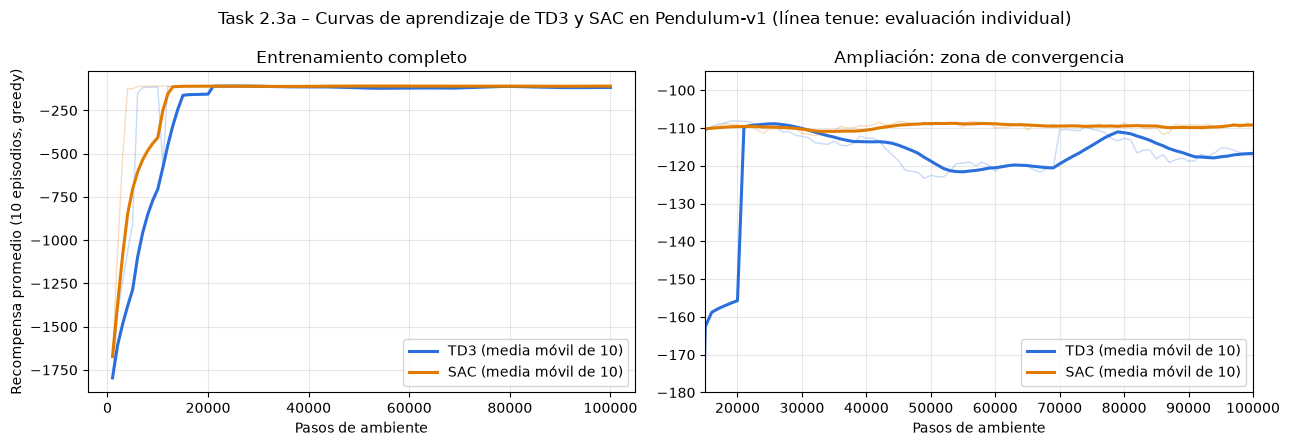

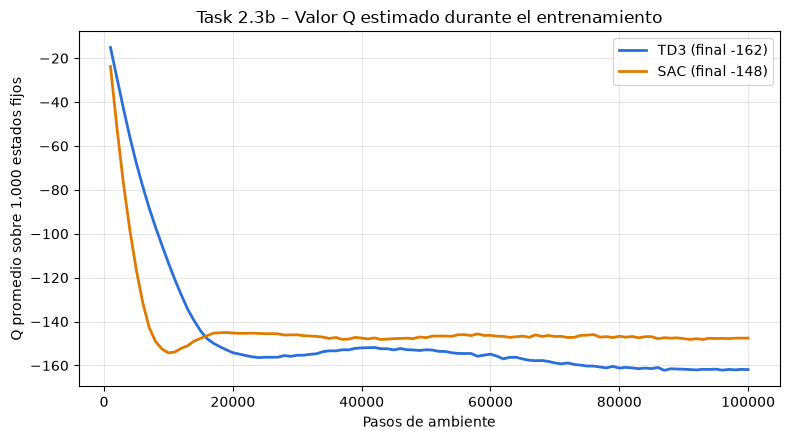

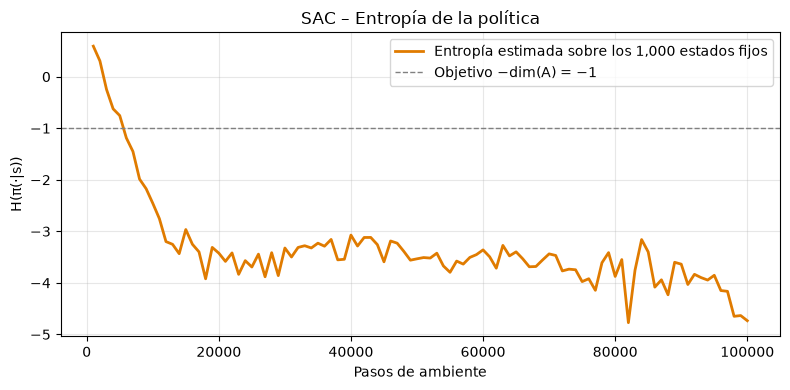

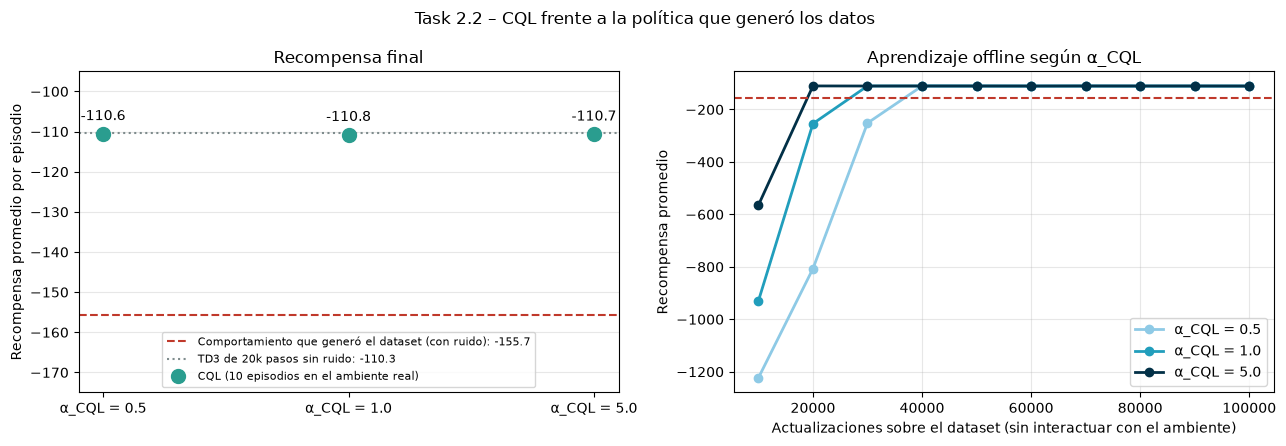

In [10]:
os.makedirs('figuras', exist_ok=True)
def media_movil(x, w=10):
    x = np.asarray(x, float)
    return np.array([x[max(0, i - w + 1): i + 1].mean() for i in range(len(x))])

COLORES = {'TD3': '#2a6fdb', 'SAC': '#e07b00'}
pasos = np.array([f['paso'] for f in registro_td3])

# ── Task 2.3a: curvas de aprendizaje (completa y ampliada en la zona de convergencia) ──
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4.5))
for reg, nombre in [(registro_td3, 'TD3'), (registro_sac, 'SAC')]:
    rec = np.array([f['recompensa'] for f in reg])
    for ax in (ax1, ax2):
        ax.plot(pasos, rec, color=COLORES[nombre], alpha=0.25, linewidth=1)
        ax.plot(pasos, media_movil(rec), color=COLORES[nombre], linewidth=2.2, label=f'{nombre} (media móvil de 10)')
ax1.set(title='Entrenamiento completo', xlabel='Pasos de ambiente', ylabel='Recompensa promedio (10 episodios, greedy)')
ax2.set(title='Ampliación: zona de convergencia', xlabel='Pasos de ambiente', xlim=(15_000, 100_000), ylim=(-180, -95))
for ax in (ax1, ax2): ax.grid(alpha=0.3); ax.legend(loc='lower right')
fig.suptitle('Task 2.3a – Curvas de aprendizaje de TD3 y SAC en Pendulum-v1 (línea tenue: evaluación individual)')
fig.tight_layout(); fig.savefig('figuras/curvas_aprendizaje.png', dpi=150); plt.show()

# ── Task 2.3b: valor Q promedio sobre el conjunto fijo ──
fig, ax = plt.subplots(figsize=(8, 4.5))
for reg, nombre in [(registro_td3, 'TD3'), (registro_sac, 'SAC')]:
    q = [f['q'] for f in reg]
    ax.plot(pasos, q, color=COLORES[nombre], linewidth=2, label=f'{nombre} (final {q[-1]:.0f})')
ax.set(xlabel='Pasos de ambiente', ylabel='Q promedio sobre 1,000 estados fijos', title='Task 2.3b – Valor Q estimado durante el entrenamiento')
ax.grid(alpha=0.3); ax.legend(); fig.tight_layout(); fig.savefig('figuras/valores_q.png', dpi=150); plt.show()

# ── Entropía de SAC ──
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(pasos, [f['entropia'] for f in registro_sac], color=COLORES['SAC'], linewidth=2, label='Entropía estimada sobre los 1,000 estados fijos')
ax.axhline(-A_DIM, color='gray', linestyle='--', linewidth=1, label='Objetivo −dim(A) = −1')
ax.set(xlabel='Pasos de ambiente', ylabel='H(π(·|s))', title='SAC – Entropía de la política')
ax.grid(alpha=0.3); ax.legend(); fig.tight_layout(); fig.savefig('figuras/entropia_sac.png', dpi=150); plt.show()

# ── Task 2.2 / 2.3c: CQL frente a la política que generó los datos ──
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4.5))
x = np.arange(len(ALPHAS_CQL))
finales = [resultados_cql[a]['final'] for a in ALPHAS_CQL]
ax1.axhline(recompensa_comportamiento, color='#c0392b', linestyle='--', linewidth=1.5, label=f'Comportamiento que generó el dataset (con ruido): {recompensa_comportamiento:.1f}')
ax1.axhline(recompensa_suboptima_greedy, color='#7f8c8d', linestyle=':', linewidth=1.5, label=f'TD3 de 20k pasos sin ruido: {recompensa_suboptima_greedy:.1f}')
ax1.plot(x, finales, 'o', color='#2a9d8f', markersize=10, label='CQL (10 episodios en el ambiente real)')
for i, v in zip(x, finales): ax1.annotate(f'{v:.1f}', (i, v), textcoords='offset points', xytext=(0, 10), ha='center')
ax1.set(xticks=x, xticklabels=[f'α_CQL = {a}' for a in ALPHAS_CQL], ylim=(-175, -95), ylabel='Recompensa promedio por episodio', title='Recompensa final')
ax1.grid(alpha=0.3, axis='y'); ax1.legend(loc='lower center', fontsize=8)
for a, color in zip(ALPHAS_CQL, ['#8ecae6', '#219ebc', '#023047']):
    curva = resultados_cql[a]['curva']
    ax2.plot([c['actualizacion'] for c in curva], [c['recompensa'] for c in curva], 'o-', color=color, linewidth=2, label=f'α_CQL = {a}')
ax2.axhline(recompensa_comportamiento, color='#c0392b', linestyle='--', linewidth=1.5)
ax2.set(xlabel='Actualizaciones sobre el dataset (sin interactuar con el ambiente)', ylabel='Recompensa promedio', title='Aprendizaje offline según α_CQL')
ax2.grid(alpha=0.3); ax2.legend(loc='lower right')
fig.suptitle('Task 2.2 – CQL frente a la política que generó los datos')
fig.tight_layout(); fig.savefig('figuras/cql.png', dpi=150); plt.show()

In [11]:
def resumen(reg, ventana=10):
    rec = media_movil([f['recompensa'] for f in reg], ventana)
    umbral = -200   # Pendulum se considera resuelto alrededor de −200 a −150
    llega = next((f['paso'] for f, m in zip(reg, rec) if m >= umbral), None)
    return {'final_media_movil': float(rec[-1]), 'mejor': float(max(f['recompensa'] for f in reg)),
            'paso_umbral_-200': llega, 'q_final': reg[-1]['q'], 'q_max': max(f['q'] for f in reg)}

resultados = {
    'td3': resumen(registro_td3), 'sac': resumen(registro_sac),
    'sac_entropia_final': registro_sac[-1]['entropia'], 'sac_alpha_final': registro_sac[-1]['alpha'],
    'comportamiento': recompensa_comportamiento, 'suboptima_greedy': recompensa_suboptima_greedy,
    'cql': {str(a): resultados_cql[a]['final'] for a in ALPHAS_CQL},
    'registros': {'td3': registro_td3, 'sac': registro_sac, 'cql': {str(a): resultados_cql[a]['curva'] for a in ALPHAS_CQL}},
}
with open('resultados.json', 'w') as f: json.dump(resultados, f, indent=1)
print(json.dumps({k: v for k, v in resultados.items() if k != 'registros'}, indent=1, ensure_ascii=False))

{
 "td3": {
  "final_media_movil": -116.71175910935358,
  "mejor": -108.10356297506814,
  "paso_umbral_-200": 15000,
  "q_final": -161.87124633789062,
  "q_max": -15.121188163757324
 },
 "sac": {
  "final_media_movil": -109.22684954649367,
  "mejor": -108.26022962970607,
  "paso_umbral_-200": 12000,
  "q_final": -147.55064392089844,
  "q_max": -23.817602157592773
 },
 "sac_entropia_final": -4.734643459320068,
 "sac_alpha_final": 0.011919088661670685,
 "comportamiento": -155.6637574259697,
 "suboptima_greedy": -110.31589103358115,
 "cql": {
  "0.5": -110.60007760532986,
  "1.0": -110.818263113558,
  "5.0": -110.70867937103222
 }
}


## Task 2.3 – Análisis de resultados

Todos los números salen de la corrida completa de este notebook (una semilla, `SEED = 0`). Con una sola semilla, las diferencias de pocas unidades de recompensa deben leerse como indicios, no como conclusiones estadísticas.

| Métrica | TD3 | SAC |
|---|---|---|
| Primera evaluación ≥ −200 (Pendulum resuelto) | 6,000 pasos | 4,000 pasos |
| Se mantiene ≥ −200 desde | 12,000 pasos (cae a −568 en el paso 11,000) | 4,000 pasos (no vuelve a caer) |
| Media móvil de 10 ≥ −200 | 15,000 pasos | 12,000 pasos |
| Recompensa en las últimas 50 evaluaciones (media ± desv.) | −117.0 ± 3.7 | −109.4 ± 0.7 |
| Media móvil final | −116.7 | −109.2 |
| Q promedio final (últimas 20 evaluaciones) | −161.6 | −147.5 |

### a. Curvas de aprendizaje

**SAC converge más rápido y alcanza una recompensa final algo mayor y mucho más estable.** Resolvió el péndulo a los 4,000 pasos y no volvió a bajar de −200. TD3 llegó a los 6,000, sufrió una recaída fuerte en el paso 11,000 (−568) y se estabilizó hasta los 12,000. En la fase final, SAC promedia −109.4 con una desviación de apenas 0.7. TD3 promedia −117.0 con una desviación de 3.7 y oscila entre −108 y −123 (gráfica ampliada).

**Esto coincide con la predicción de la Task 1.1b.** El objetivo de máxima entropía de SAC explora sin calibrar el ruido a mano y llega antes a buen desempeño (mejor eficiencia de datos). Además, su política se mantiene estable. La exploración de TD3 depende de un ruido gaussiano fijo ($\sigma=0.1$) y de un actor determinista que sigue un crítico todavía inexacto, lo que explica la recaída temprana y la oscilación posterior.

**Matiz.** `Pendulum-v1` es un problema sencillo, y ambos algoritmos terminan muy cerca del óptimo. La diferencia final (unas 8 unidades por episodio) es pequeña frente a la diferencia en estabilidad y velocidad, que es la que importa para la recomendación de producción.

### b. Valor Q estimado

**TD3 estima valores consistentemente más bajos que SAC:** −161.6 frente a −147.5 al final, una brecha de unos 14 puntos (≈ 9 %) que se mantiene después del paso 20,000. Al inicio ambos parten cerca de 0 y bajan a medida que el crítico aprende que el péndulo cuesta recompensa negativa en cada paso.

**Esto confirma el análisis de conservatividad de la Task 1.2b.** Ambos usan el mínimo de dos críticos, pero TD3 no añade nada que compense ese sesgo hacia abajo. Su *target policy smoothing* además promedia $Q$ sobre una vecindad de la acción, lo que recorta los picos. El target de SAC suma $-\alpha\log\pi$, así que su *soft Q* incluye el bono de entropía de los pasos futuros. Como $\alpha$ terminó muy pequeño (≈ 0.012), ese bono explica solo una parte de la brecha. El resto es consistente con el sesgo hacia abajo del *clipped double-Q* sin compensación en TD3, aunque con una sola semilla no podemos separar del todo ambos efectos.

**Sobre la entropía de SAC.** La gráfica muestra $\alpha$ bajando de 0.80 a 0.012 y la entropía estimada por debajo del objetivo de −1. No es una contradicción. La entropía se mide sobre los 1,000 estados fijos, que provienen de una política aleatoria: en su mayoría son estados de balanceo, donde la acción óptima es un torque máximo de ±2. Allí la política satura en $\tanh(u)\approx\pm1$, y la corrección $-\log(1-\tanh^2 u)$ vuelve la densidad muy concentrada, con entropía muy negativa. $\alpha$, en cambio, se ajusta con los estados del buffer, que tras converger son mayoritariamente cercanos a la posición vertical, donde la política no satura.

### c. CQL frente a la política que generó los datos

**Los tres valores de $\alpha_{\text{CQL}}$ superan a la política que generó el dataset:** −110.6 (α = 0.5), −110.8 (α = 1.0) y −110.7 (α = 5.0), frente a −155.7 de la política de comportamiento con ruido $\mathcal{N}(0, 0.3)$. Es una mejora de unos 45 puntos (≈ 29 %), lograda sin una sola interacción con el ambiente durante el entrenamiento.

**El valor final es prácticamente igual en los tres casos.** Las diferencias de 0.2 puntos están dentro del ruido de evaluación. La diferencia está en **cómo aprenden**:

| $\alpha_{\text{CQL}}$ | Supera al comportamiento desde | Q promedio final |
|---|---|---|
| 0.5 | 40,000 actualizaciones | −158.3 |
| 1.0 | 30,000 actualizaciones | −165.5 |
| 5.0 | 20,000 actualizaciones | −179.0 |

**El mejor es $\alpha_{\text{CQL}} = 5.0$.** Llega a la misma recompensa final con la mitad de actualizaciones, y sus valores $Q$ son los más conservadores. Con α bajo, el crítico pasa las primeras decenas de miles de actualizaciones sobrevalorando acciones que no están en los datos, y la política llega a −1,224 tras 10,000 actualizaciones. Cuanto más fuerte es la penalización, antes se descartan esas acciones y antes la política se ancla a lo que el dataset respalda. Al final, la brecha del regularizador (log-sum-exp menos $Q$ de los datos) es negativa en los tres casos, más con α = 5 (−1.31 frente a −0.92 con α = 0.5): el crítico valora las acciones del dataset por encima de las no observadas, que es justo el efecto buscado.

**¿Por qué ningún α supera a la política subóptima *sin ruido* (−110.3)?** Por cómo resultó el dataset. En `Pendulum-v1`, 20,000 pasos de TD3 bastaron para casi converger (−110.3), así que el dataset no es "malo": es una buena política con ruido. CQL recuperó la política subyacente y eliminó el ruido, y de ahí sale la mejora de 45 puntos. No pudo ir más allá porque los datos vienen de **una sola política** con ruido gaussiano moderado: la cobertura se concentra alrededor de sus propias trayectorias y no hay acciones claramente mejores registradas que aprovechar. Es exactamente la limitación de cobertura de la Task 1.1c, en una versión pequeña.

### d. Cuándo usar TD3/SAC frente a CQL en las turbinas reales

| Factor | Favorece online (TD3/SAC) | Favorece offline (CQL) |
|---|---|---|
| Simulador confiable | Existe y modela bien el viento y las cargas | No existe o no es fiel al sistema real |
| Costo de interactuar con el sistema real | Solo se interactúa con el simulador | Cada error en la turbina real cuesta dinero o daño físico |
| Calidad del dataset histórico | Pobre o con cobertura muy estrecha | Buena: incluye operadores expertos |
| Urgencia de despliegue | Hay tiempo para entrenar y validar | Se necesita algo útil pronto |

**Recomendación con base en los experimentos:**
1. **Si hay un simulador confiable, usar SAC** (entrenado online y desplegado con la acción determinista $\tanh(\mu)$). En nuestros resultados fue el más rápido (4,000 pasos frente a 6,000) y, sobre todo, el más estable (desv. 0.7 frente a 3.7 de TD3). Ese es el criterio clave para un sistema físico.
2. **Si no hay simulador o la urgencia es alta, usar CQL con $\alpha_{\text{CQL}}$ alto (≈ 5)** sobre los registros históricos. En nuestro experimento superó en 29 % a la política que generó los datos sin interactuar con el ambiente, y α = 5 convergió el doble de rápido con valores más conservadores. Es lo que conviene cuando un error se paga con daño al equipo.
3. **No esperar que CQL descubra estrategias mejores que las de los mejores operadores.** Igualó a la mejor política presente en los datos (−110.7 frente a −110.3), pero no la superó, por la cobertura limitada. Si el objetivo es ganarles a los operadores expertos, hace falta exploración, y eso solo es seguro en simulación.
4. **La ruta más práctica combina ambos:** CQL sobre los datos históricos para tener pronto una política inicial segura, y después un ajuste fino online en el simulador con SAC antes del despliegue gradual en la turbina real.

### Task 2.3e – Investigación bibliográfica

**Paper:** S. Yang y Y. Zhu, *"Offline Reinforcement Learning for Microgrid Voltage Regulation"*, presentado en ICLR 2025 (Singapur, 28 de abril de 2025, según el comentario de los autores en [arXiv:2505.09920](https://arxiv.org/abs/2505.09920)).
> Pendiente de verificar: en la página de ICLR 2025, si se publicó en la conferencia principal o en uno de sus workshops, para ajustar la cita.

**Problema.** Regular el voltaje de una microrred con alta penetración solar fotovoltaica (red de prueba IEEE de 33 nodos), en un escenario donde interactuar con el sistema real para entrenar no es viable por razones técnicas o de seguridad. Es el mismo argumento que hace atractivo Offline RL para las turbinas.
- **Estado:** cargas activas y reactivas, generación FV y magnitud del voltaje en cada nodo.
- **Acción (continua):** la proporción de potencia reactiva que inyecta cada inversor FV.
- **Recompensa:** penaliza la desviación de voltaje y, con menor peso, el uso de potencia reactiva.

**Algoritmos y por qué.** Comparan **BCQ** y **CQL**, porque ambos atacan el error de extrapolación con mecanismos distintos. BCQ restringe las acciones a las que un modelo generativo (VAE) considera probables bajo los datos. CQL penaliza los valores $Q$ de las acciones fuera de la distribución, como en nuestra Task 1.2c.

**Datos.** Tres datasets de 200,000 transiciones cada uno:
- **Expert:** generado por un agente DDPG bien entrenado.
- **Medium:** el experto con 5 % de ruido gaussiano en las acciones.
- **Poor:** acciones completamente aleatorias.

**Resultados principales.**
- Con datos expertos, ambos algoritmos aprenden políticas que mantienen el voltaje dentro de la banda de 0.95–1.05 p.u.; CQL es algo más estable.
- Con datos de baja calidad, **CQL supera a BCQ**: logra mayor proporción de nodos controlados y menor desviación de voltaje. Los autores lo atribuyen a la estimación conservadora de $Q$.

**Reflexión frente a la Task 1.1c.**
- **Calidad de los datos:** el trabajo la estudia de forma explícita (expert/medium/poor) y muestra que CQL tolera datos malos mejor que BCQ. Es nuestro mismo argumento: los operadores novatos degradan la calidad de $\beta$, y CQL es la opción más robusta a eso.
- **Cobertura:** es la limitación que **no** aparece bien representada. Su dataset *poor* es aleatorio y por eso cubre casi todo el espacio estado-acción, que es justo lo contrario de un dataset humano. Un registro histórico de operadores tiene buena calidad parcial pero cobertura estrecha. El paper no analiza ese caso, ni el cambio de distribución hacia estados raros. Además, todo se evalúa en simulación y no en una red real.
- **Para nuestro caso:** sus conclusiones a favor de CQL son un buen indicio, pero habría que medir explícitamente la cobertura del dataset de turbinas y validar en simulación antes de confiar en la política. Es lo mismo que observamos en la Task 2.2: el dataset proviene de una sola política subóptima con ruido moderado.